In [10]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import numpy as np
import torch.nn.functional as F


In [3]:
# Set device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the transformations (Normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize the dataset to range [-1, 1]
])

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 759kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.17MB/s]


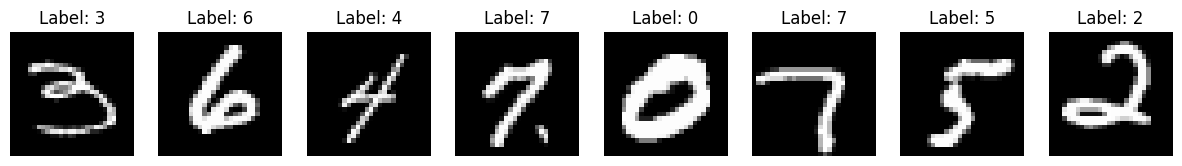

In [4]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Define the transformation (convert image to tensor and normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # mean=0.5, std=0.5
])

# ✅ Download and load the training and test sets
train_dataset = datasets.MNIST(
    root='./data',         # folder to store the dataset
    train=True,            # training set
    transform=transform,   # apply transformations
    download=True          # download if not already present
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,           # test set
    transform=transform,
    download=True
)

# Create DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# ✅ Visualize some images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Unnormalize for visualization
images = images * 0.5 + 0.5  # reverse normalization

# Plot the first 8 images
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i in range(8):
    axes[i].imshow(images[i][0], cmap='gray')
    axes[i].set_title(f'Label: {labels[i]}')
    axes[i].axis('off')
plt.show()


In [5]:
#  Define the neural network model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        # Define the layers
        self.fc1 = nn.Linear(28*28, 128)  # First hidden layer
        self.fc2 = nn.Linear(128, 64)     # Second hidden layer
        self.fc3 = nn.Linear(64, 10)      # Output layer (10 classes)

    def forward(self, x):
        # Flatten the image
        x = x.view(-1, 28*28)
        # First fully connected layer + activation
        x = F.relu(self.fc1(x))
        # Second fully connected layer + activation
        x = F.relu(self.fc2(x))
        # Output layer (no activation here; use CrossEntropyLoss which applies Softmax internally)
        x = self.fc3(x)
        return x


In [6]:
# Initialize the model, loss function, and optimizer
model = ANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# ✅ Training the network
num_epochs = 5  # you can increase this to 10 or more for better accuracy
ls_losses = []

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # 1️⃣ Move images and labels to the device
        images = images.to(device)  # images are already in (batch, 1, 28, 28)
        labels = labels.to(device)

        # 2️⃣ Forward pass
        outputs = model(images)             # pass images through model
        loss = criterion(outputs, labels)   # compute loss
        ls_losses.append(loss.item())       # store loss (use .item() instead of numpy())

        # 3️⃣ Backward and optimize
        optimizer.zero_grad()  # reset gradients to zero
        loss.backward()        # compute gradients (backpropagation)
        optimizer.step()       # update model parameters

        # 4️⃣ Print progress every 100 steps
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')


Epoch [1/5], Step [100/938], Loss: 0.5318
Epoch [1/5], Step [200/938], Loss: 0.2232
Epoch [1/5], Step [300/938], Loss: 0.3725
Epoch [1/5], Step [400/938], Loss: 0.3200
Epoch [1/5], Step [500/938], Loss: 0.3623
Epoch [1/5], Step [600/938], Loss: 0.3720
Epoch [1/5], Step [700/938], Loss: 0.2684
Epoch [1/5], Step [800/938], Loss: 0.2532
Epoch [1/5], Step [900/938], Loss: 0.3405
Epoch [2/5], Step [100/938], Loss: 0.3098
Epoch [2/5], Step [200/938], Loss: 0.1814
Epoch [2/5], Step [300/938], Loss: 0.2885
Epoch [2/5], Step [400/938], Loss: 0.1042
Epoch [2/5], Step [500/938], Loss: 0.1793
Epoch [2/5], Step [600/938], Loss: 0.3233
Epoch [2/5], Step [700/938], Loss: 0.1251
Epoch [2/5], Step [800/938], Loss: 0.0948
Epoch [2/5], Step [900/938], Loss: 0.1058
Epoch [3/5], Step [100/938], Loss: 0.1428
Epoch [3/5], Step [200/938], Loss: 0.1859
Epoch [3/5], Step [300/938], Loss: 0.0711
Epoch [3/5], Step [400/938], Loss: 0.1545
Epoch [3/5], Step [500/938], Loss: 0.1439
Epoch [3/5], Step [600/938], Loss:

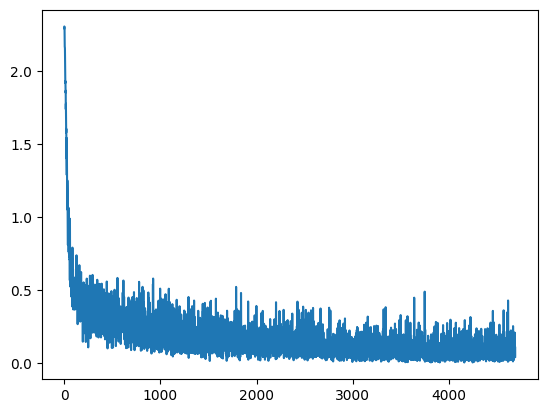

In [12]:
# Plot Losses
x_axis = np.arange(0, len(ls_losses), 1)
plt.plot(x_axis, ls_losses)
plt.xlabel = "Sample"
plt.ylabel = "Loss"

In [13]:
#  Testing the model
model.eval()  # Set the model to evaluation mode
all_preds = []
all_labels = []

with torch.no_grad():  # No gradients needed during evaluation
    correct = 0
    total = 0
    for images, labels in test_loader:
        # Move images and labels to the device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)  # Pass images through the network
        _, predicted = torch.max(outputs.data, 1)  # Get the class with highest score

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Store predictions and actual labels for metrics
        all_preds.extend(predicted.cpu().numpy())  # move to CPU and convert to numpy
        all_labels.extend(labels.cpu().numpy())

    print(f'Accuracy of the network on the test images: {100 * correct / total:.2f}%')


Accuracy of the network on the test images: 96.63%


Accuracy: 96.63%
Precision: 0.9669
Recall: 0.9660
F1-Score: 0.9662


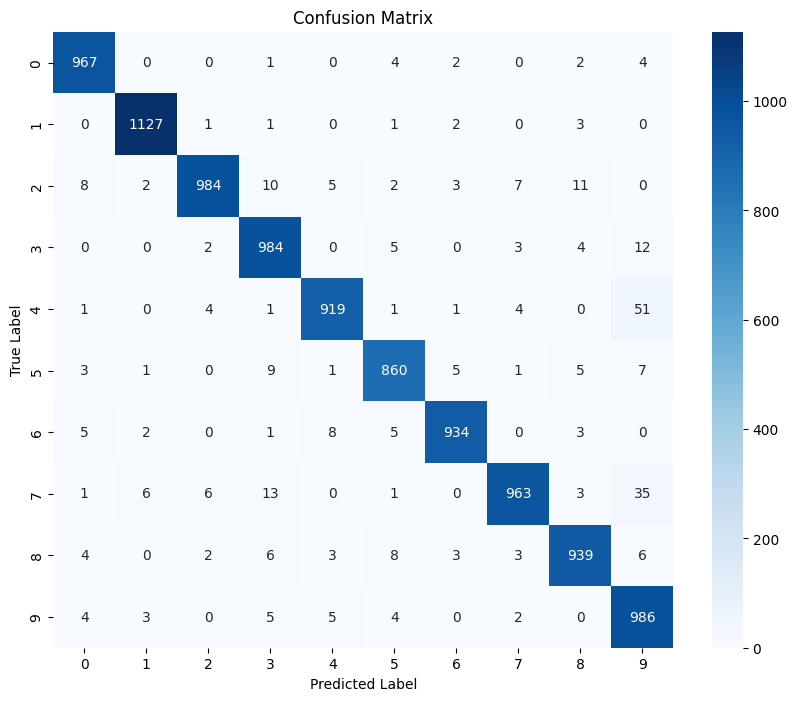

In [23]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Convert predictions and labels to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ✅ Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')  # average='macro' for multi-class
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

# ✅ Confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)


plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[i for i in range(10)], yticklabels=[i for i in range(10)])
plt.title('Confusion Matrix')

# Safe way to set labels without calling plt.ylabel/plt.xlabel
plt.gca().set_ylabel('True Label')
plt.gca().set_xlabel('Predicted Label')

plt.show()



In [24]:
# Define hyperparameters to tune
param_grid = {
    'learning_rate': [0.001, 0.005, 0.01],
    'batch_size': [32, 64, 128],
    'num_epochs': [3, 5]  # Use small numbers for quick tuning
}

best_accuracy = 0
best_params = {}

# Iterate through hyperparameter combinations
for lr in param_grid['learning_rate']:
    for bs in param_grid['batch_size']:
        for epochs in param_grid['num_epochs']:
            print(f"\nTraining with LR: {lr}, Batch Size: {bs}, Epochs: {epochs}")

            # Re-initialize model, loss, and optimizer
            model = ANN().to(device)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)

            # Update DataLoader with new batch size
            train_loader = DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)
            test_loader = DataLoader(dataset=test_dataset, batch_size=bs, shuffle=False)

            model.train()

            # Training loop
            for epoch in range(epochs):
                for i, (images, labels) in enumerate(train_loader):
                    images = images.to(device).view(-1, 28*28)
                    labels = labels.to(device)

                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

            # Evaluation loop
            model.eval()
            with torch.no_grad():
                correct = 0
                total = 0
                for images, labels in test_loader:
                    images = images.to(device).view(-1, 28*28)
                    labels = labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                accuracy = 100 * correct / total  # ✅ Calculate accuracy in percentage
                print(f'Accuracy for LR: {lr}, Batch Size: {bs}, Epochs: {epochs}: {accuracy:.2f}%')

                # Store best parameters
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_params = {'learning_rate': lr, 'batch_size': bs, 'num_epochs': epochs}

print("\nBest Hyperparameters:")
print(best_params)
print(f"Best Accuracy: {best_accuracy:.2f}%")



Training with LR: 0.001, Batch Size: 32, Epochs: 3
Accuracy for LR: 0.001, Batch Size: 32, Epochs: 3: 96.35%

Training with LR: 0.001, Batch Size: 32, Epochs: 5
Accuracy for LR: 0.001, Batch Size: 32, Epochs: 5: 96.08%

Training with LR: 0.001, Batch Size: 64, Epochs: 3
Accuracy for LR: 0.001, Batch Size: 64, Epochs: 3: 95.82%

Training with LR: 0.001, Batch Size: 64, Epochs: 5
Accuracy for LR: 0.001, Batch Size: 64, Epochs: 5: 97.03%

Training with LR: 0.001, Batch Size: 128, Epochs: 3
Accuracy for LR: 0.001, Batch Size: 128, Epochs: 3: 95.30%

Training with LR: 0.001, Batch Size: 128, Epochs: 5
Accuracy for LR: 0.001, Batch Size: 128, Epochs: 5: 96.19%

Training with LR: 0.005, Batch Size: 32, Epochs: 3
Accuracy for LR: 0.005, Batch Size: 32, Epochs: 3: 94.33%

Training with LR: 0.005, Batch Size: 32, Epochs: 5
Accuracy for LR: 0.005, Batch Size: 32, Epochs: 5: 94.50%

Training with LR: 0.005, Batch Size: 64, Epochs: 3
Accuracy for LR: 0.005, Batch Size: 64, Epochs: 3: 94.77%

Train

In [25]:

import torch.optim as optim

# ✅ Define regularized ANN with Dropout
class ANN_Regularized(nn.Module):
    def __init__(self):
        super(ANN_Regularized, self).__init__()
        # Layer definitions
        self.fc1 = nn.Linear(28*28, 128)  # First hidden layer: 128 units
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)   # Dropout probability: 30%
        self.fc2 = nn.Linear(128, 64)    # Second hidden layer: 64 units
        self.fc3 = nn.Linear(64, 10)     # Output layer: 10 classes

    def forward(self, x):
        x = x.view(-1, 28*28)    # Flatten the image
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# ✅ Initialize the regularized model
model_regularized = ANN_Regularized().to(device)

# ✅ Define loss function and optimizer
criterion_regularized = nn.CrossEntropyLoss()           # same as before
optimizer_regularized = optim.Adam(model_regularized.parameters(), lr=0.001)

print("Regularized ANN model defined with dropout layers.")


Regularized ANN model defined with dropout layers.
